# **Cleaning up Data from Outliers**

In [1]:
import sys
sys.path;
#!pip install virtualenv
#!virtualenv /content/drive/MyDrive/virtual_env


In [2]:
#!source /content/drive/MyDrive/virtual_env/bin/activate; pip install pyod

In [3]:
#sys.path.append("/content/drive/MyDrive/virtual_env/lib/python3.10/site-packages")

In [4]:
# foundation packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# dislay all outputs in a cell (https://rb.gy/lbz7hn)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Set numpy print options
np.set_printoptions(linewidth=500)  # Set a large width to display more columns in one line
pd.set_option('display.width',1000) # set a large width for datamatrix display

# Definition

* Outliers are observations that are significantly different from other data points.
* They are rare, distinct, or do not fit in some way.
* samples that are exceptionally far from the mainstream of the data.

#Reason
>There can be many reasons for the presence of outliers in the data.
* Natural Variability: Sometimes the outliers may be genuine,
* Data entry errors: Wrong entry, typo
* Sampling Errors:sample isn't representative of the population
* Measurement Errors: technical glitches, faulty sensors, wrong measurements

# **Detection/Identification**

Outlier detection methods fall into several categories, including statistical, proximity-based, and machine learning techniques. The best method depends on your dataset's characteristics, such as size, dimensionality, and data distribution.
1. **Statistical**
    * **z-score:** Calculates how many standard deviations a data point is from the mean. A data point is flagged as an outlier if its Z-score is above a certain threshold (e.g., 2.5, 3, or greater).
    * **IQR:** Divides a dataset into quartiles and is more robust to skewed data than the Z-score method. It defines outliers as any points that fall outside the upper and lower fences.
    * **stdev:** Similar to z-score method
    * **boxplot:** A visual representation of the IQR method, where outliers are displayed as individual points or asterisks outside the whiskers of the box.
2. **Proximity based:** These techniques identify outliers based on their distance or density relative to their neighbors. Outliers are located in areas of low density, far from other data points.
    * **Local Outlier Factor** (LOF): A *density-based* method that calculates an outlier score by comparing a data point's local density to the average local density of its neighbors. A score significantly greater than 1 indicates an outlier.
    * **Distance-based** methods: Define a data point as an outlier if a given number of its neighbors are farther away than a specified distance. It is effective for datasets with numerical values but can be computationally expensive for high-dimensional data. eg., KNN
    
3. **Clustering based:** Uses clustering algorithms, like K-means, where data points that do not belong to any cluster or are very far from the center of a cluster are flagged as outliers.
    * **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise): A clustering algorithm that groups together closely packed data points and marks as outliers any points that lie alone in low-density regions.
    * Hierarchical clustering
  
4. **othe ML methods** For complex or high-dimensional datasets,
    * **Isolation Forest:** A tree-based ensemble method that "isolates" outliers by randomly selecting a feature and then a split value. Outliers require fewer random splits to be isolated because they are rare and have values that are far from the majority of data.
    * **One-Class Support Vector Machine** (SVM): An unsupervised algorithm that learns a boundary surrounding a "normal" dataset. Data points that fall outside this boundary are classified as outliers. This is best for novelty detection, where the model is trained on a clean dataset with no outliers.
    * **Autoencoders:** A type of neural network that can be trained to learn the compressed representation of normal data. During testing, the network will have a high reconstruction error for an outlier, indicating that it is anomalous.

## How to choose a method
When deciding on an outlier detection method, consider the following factors:
1. **Distribution:**
    * For `normally distributed` data, the `Z-score` is appropriate.
    * For `skewed or non-normal` data, the `IQR` method is more robust.
1. **Dimensionality:**
    * For high-dimensional datasets, ML algorithms like `Isolation Forest` are often more effective than traditional methods, which can struggle with the "curse of dimensionality".
1. **Computational cost:**
    * Statistical methods are generally faster,
    * while proximity-based and some ML methods can be more computationally intensive for large datasets.
1. **Interpretability:**
    * Visual inspection and statistical methods offer intuitive and easy-to-interpret results,
    * whereas complex ML methods may provide less transparent results.

#1. Univariate Outlier Detection

Outliers occur within a single variable. Outliers are detected by the following  methods:  
## 1. Numerical/Quantitative methods
  * describe
  * IQR
  * skewness
  * z-score
  * Modified Z-scores:
    * Uses the `median` and `Median Absolute Deviation` (MAD) instead of `mean` and `standard deviation`
    * more robust for skewed data.
## 2. Visualization methods
  * Boxplot
  * Histogram
  * Scatterplot

> Mean is the only measure of central tendency that is affected by the outlier treatment which in turn impacts Standard deviation.

**Python Implementation**

In [6]:
#Load "diamonds" dataset
df=sns.load_dataset('diamonds')
df.head()
df.shape

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


(53940, 10)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [8]:
# Remove all (categorical variables) columns between column index 1 to 3
dfnum=df.drop(df.iloc[:, 1:4], axis=1)  #delete multiple columns based on column numbers
# dfnum=df.drop(['cut','color','clarity'], axis = 1) #delete multiple columns based on columns names
dfnum.head(3)

,carat,depth,table,price,x,y,z
0,0.23,61.5,55.0,326,3.95,3.98,2.43
1,0.21,59.8,61.0,326,3.89,3.84,2.31
2,0.23,56.9,65.0,327,4.05,4.07,2.31


## 1 Numerical Methods

###1.1 Describe
  * `describe()`function provides a statistical summary of all the quantitative variables.

In [9]:
dfnum.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [10]:
dfnum.isna().sum()

carat    0
depth    0
table    0
price    0
x        0
y        0
z        0
dtype: int64

In [11]:
dfnum['table']

0        55.0
1        61.0
2        65.0
3        58.0
4        58.0
         ... 
53935    57.0
53936    55.0
53937    60.0
53938    58.0
53939    55.0
Name: table, Length: 53940, dtype: float64

###1.2 IQR

  * a measure of statistical dispersion
  * the difference between the 75th and 25th percentiles IQR = Q3 − Q1.
  * scores that lie 1.5 times of IQR above Q3 and below Q1 are outliers.

![](https://editor.analyticsvidhya.com/uploads/12311IQR.png)

**Steps**
1. Sort the dataset in ascending order
1. calculate the 1st and 3rd quartiles(Q1, Q3)
1. compute IQR=Q3-Q1
1. compute lower bound = (Q1–1.5*IQR), upper bound = (Q3+1.5*IQR)





In [12]:
sample= [15, 101, 18, 7, 13, 16, 11, 21, 5, 15, 10, 9]
def detect_outliers_iqr(data):
    data = sorted(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    # print(q1, q3)
    IQR = q3-q1
    lwr_bound = q1-(1.5*IQR)
    upr_bound = q3+(1.5*IQR)
    # print(lwr_bound, upr_bound)
    outliers = [i for i in data if (i<lwr_bound or i>upr_bound)]
    return outliers# Driver code
sample_outliers = detect_outliers_iqr(sample)
print("Outliers from IQR method: ", sample_outliers)

Outliers from IQR method:  [101]


In [13]:
Q1 = dfnum.quantile(0.25)
print(Q1)

carat      0.40
depth     61.00
table     56.00
price    950.00
x          4.71
y          4.72
z          2.91
Name: 0.25, dtype: float64


In [14]:
Q3 = dfnum.quantile(0.75)
print(Q3)

carat       1.04
depth      62.50
table      59.00
price    5324.25
x           6.54
y           6.54
z           4.04
Name: 0.75, dtype: float64


In [15]:
IQR = Q3 - Q1
print(IQR)

carat       0.64
depth       1.50
table       3.00
price    4374.25
x           1.83
y           1.82
z           1.13
dtype: float64


In [16]:
df1 = dfnum[~((dfnum.lt (Q1 - 1.5 * IQR)) |(dfnum.gt (Q3 + 1.5 * IQR))).any(axis=1)]

print(df1)

       carat  depth  table  price     x     y     z
0       0.23   61.5   55.0    326  3.95  3.98  2.43
1       0.21   59.8   61.0    326  3.89  3.84  2.31
3       0.29   62.4   58.0    334  4.20  4.23  2.63
4       0.31   63.3   58.0    335  4.34  4.35  2.75
5       0.24   62.8   57.0    336  3.94  3.96  2.48
...      ...    ...    ...    ...   ...   ...   ...
53935   0.72   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75   62.2   55.0   2757  5.83  5.87  3.64

[47524 rows x 7 columns]


In [17]:
df2 = dfnum[~((dfnum.le(Q1 - 1.5 * IQR)) |(dfnum.ge (Q3 + 1.5 * IQR))).all(axis=1)]

print(df2)

       carat  depth  table  price     x     y     z
0       0.23   61.5   55.0    326  3.95  3.98  2.43
1       0.21   59.8   61.0    326  3.89  3.84  2.31
2       0.23   56.9   65.0    327  4.05  4.07  2.31
3       0.29   62.4   58.0    334  4.20  4.23  2.63
4       0.31   63.3   58.0    335  4.34  4.35  2.75
...      ...    ...    ...    ...   ...   ...   ...
53935   0.72   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75   62.2   55.0   2757  5.83  5.87  3.64

[53940 rows x 7 columns]


### 1.3 Skewness

* The skewness value should be between -1 and +1, and any major deviation from this range indicates the presence of extreme values.
* Apply transformation if skewness is high.
```
if np.abs(skewness) > 1:
        print(f"Transforming column {col} due to high skewness.")
        dfnum[col] = np.log1p(dfnum[col] - dfnum[col].min() + 1)
```



In [18]:
dfnum.skew()

carat    1.116646
depth   -0.082294
table    0.796896
price    1.618395
x        0.378676
y        2.434167
z        1.522423
dtype: float64

### 1.4 Z-score

* Any data point whose Z-score falls out of 3rd standard deviation is an outlier.

![zcurve.png](https://cdn.analyticsvidhya.com/wp-content/uploads/2023/09/image-76.png)




In [19]:
def detect_outliers_zscore(data):
    thres = 3
    mean = np.mean(data)
    std = np.std(data)
    # print(mean, std)
    outliers = [i for i in data if np.abs((i - mean) / std) > thres] #list comprehension
    return outliers# Driver code
sample_outliers = detect_outliers_zscore(sample)
print("Outliers from Z-scores method: ", sample_outliers)

Outliers from Z-scores method:  [101]


### 1.5 Standard deviation

* A value that falls outside of 3 standard deviations is part of the distribution, but it is an unlikely or rare event at approximately 1 in 370 samples.
* 3 σ from the mean is a common cut-off in practice for identifying outliers in a Gaussian or Gaussian-like distribution.

In [20]:
def detect_outliers_stdv(data):
    data_mean, data_std = np.mean(data), np.std(data)
    # print(mean, std)
    # define outliers
    cut_off = data_std * 3
    lower, upper = data_mean - cut_off, data_mean + cut_off
    # identify outliers
    outliers = [i for i in data if i < lower or i > upper] #list comprehension
    return outliers# Driver code
sample_outliers = detect_outliers_stdv(sample)
print("Outliers from Standard dev method: ", sample_outliers)

Outliers from Standard dev method:  [101]


## 2 Visualization/Graphical Methods

Some of the common plots used for outlier detection are

### 2.1 Box Plot
>* The box plot is a standardized way of displaying the distribution of data based on the five-number summary (minimum, first quartile (Q1), median, third quartile (Q3), and maximum).
* It is often used to identify data distribution and detect outliers.

<Axes: xlabel='table'>

<Axes: xlabel='price'>

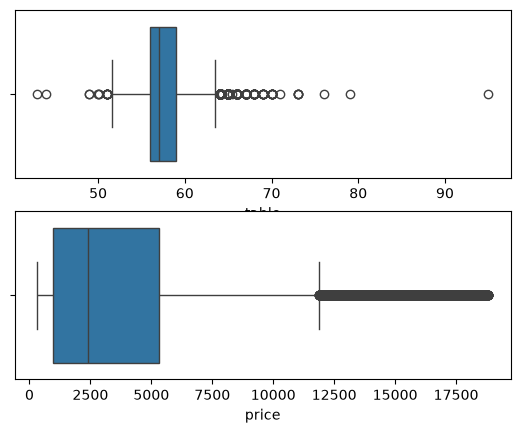

In [21]:
fig, axs = plt.subplots(nrows=2)
sns.boxplot(data=df, x='table', ax=axs[0])
sns.boxplot(data=df, x='price', ax=axs[1])


<Axes: xlabel='table'>

<Axes: title={'center': 'table'}, xlabel='cut'>

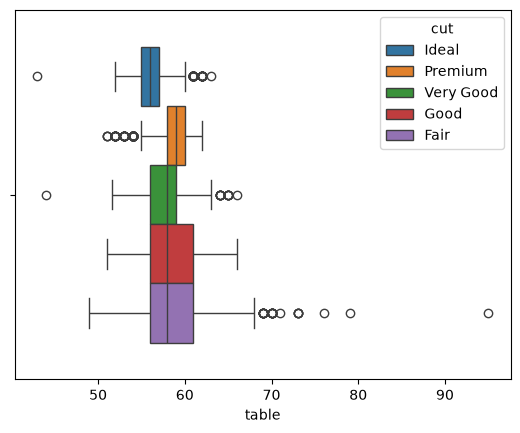

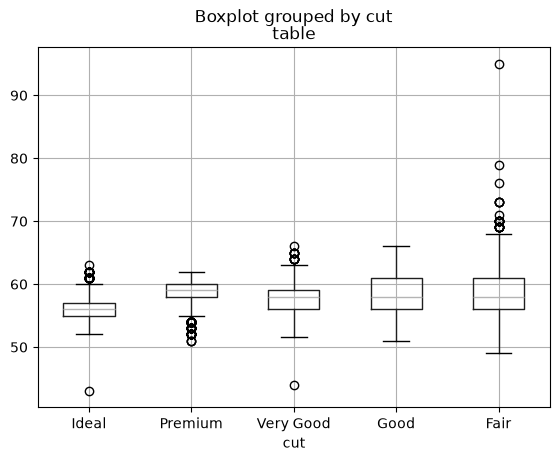

In [22]:
sns.boxplot(data=df,x='table', hue='cut')
df.boxplot(column='table', by='cut')

### 2.2 Histogram
* A histogram is used to visualize the distribution of a numerical variable.
* An outlier will appear outside the overall pattern of distribution.

array([[<Axes: title={'center': 'carat'}>, <Axes: title={'center': 'depth'}>, <Axes: title={'center': 'table'}>],
       [<Axes: title={'center': 'price'}>, <Axes: title={'center': 'x'}>, <Axes: title={'center': 'y'}>],
       [<Axes: title={'center': 'z'}>, <Axes: >, <Axes: >]], dtype=object)

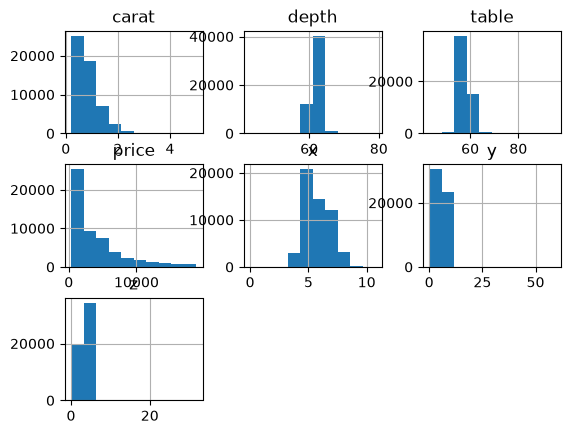

In [23]:
dfnum.hist()

### 2.3 Scatterplot
>* A scatterplot visualizes the relationship between two numerical variables.
* The data are displayed as a collection of points, and any points that fall outside the general clustering of the two variables may indicate outliers.

<Axes: xlabel='depth', ylabel='carat'>

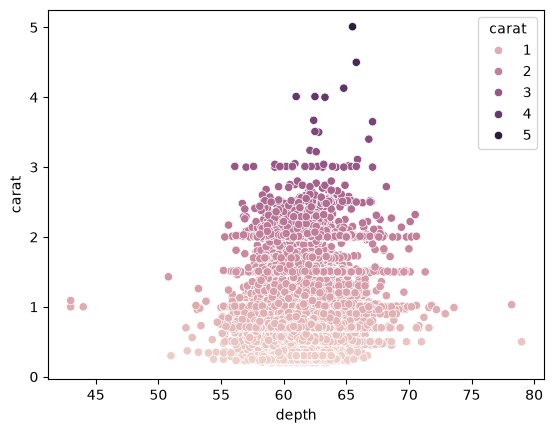

In [24]:
sns.scatterplot(data=df,x='depth',y='carat',hue='carat')

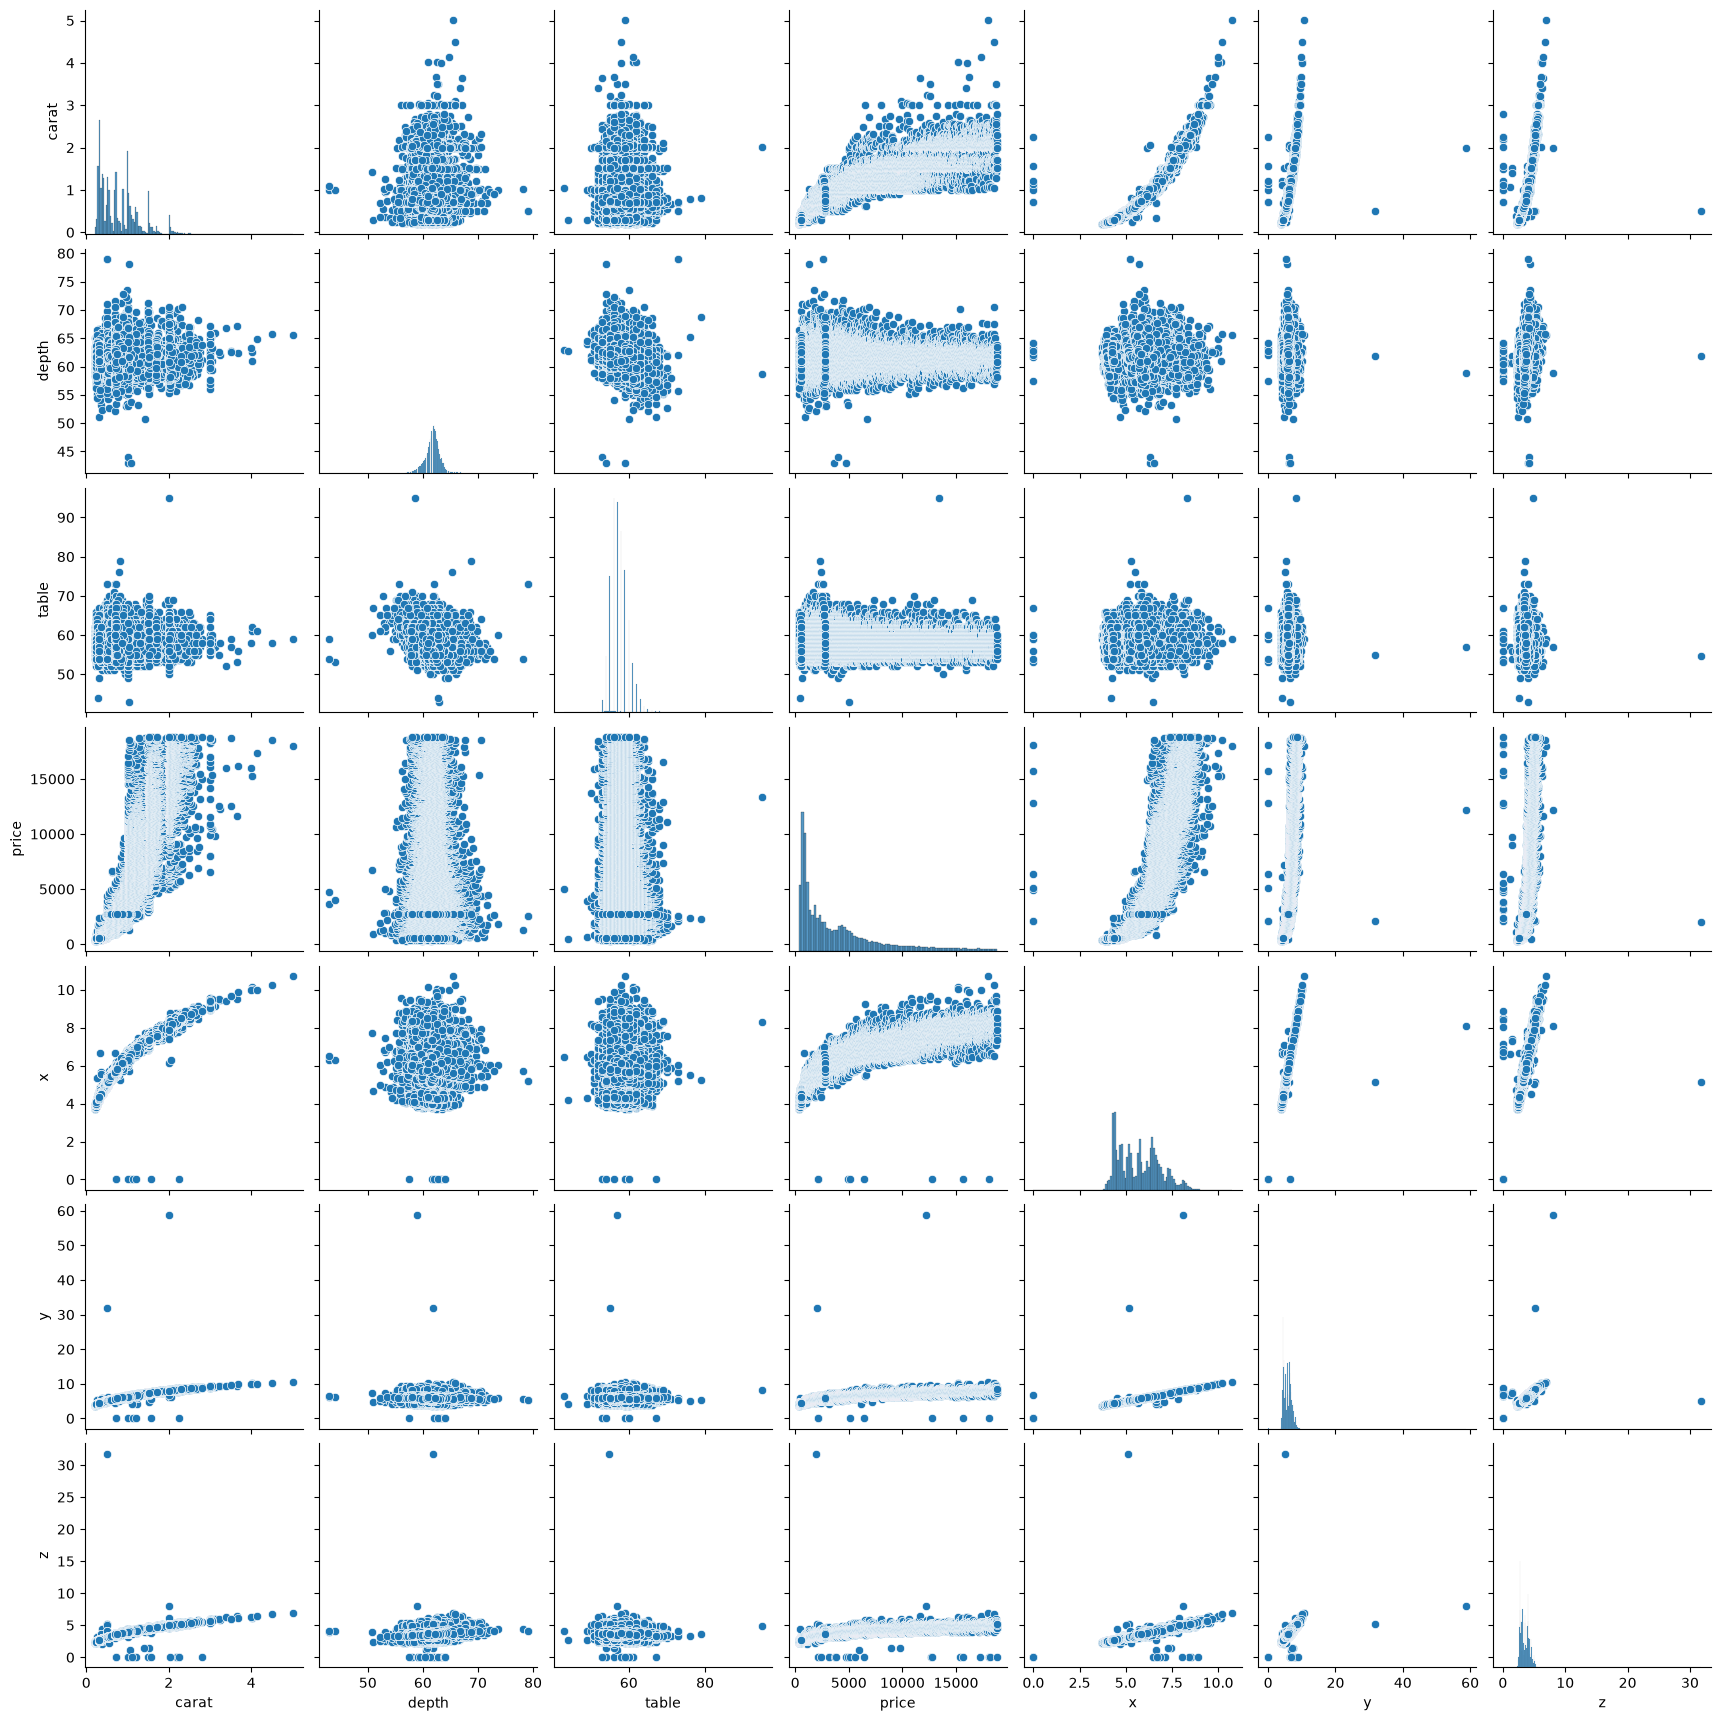

In [25]:
sns.pairplot(dfnum)

#2. Multivariate Outlier Detection

1. Isolation Forest:
  * Isolates anomalies faster than normal data during random partitioning.
1. Local Outlier Factor (LOF):
  * Identifies outliers based on local density deviation from neighbors.
1. Clustering Techniques (K-means, Hierarchical):
  * Detect points far from established clusters or in small clusters.
1. Angle-based Outlier Detection (ABOD):
  * Analyzes angles between data points in high dimensions.

#3. Machine Learning Based Approaches

1. **Density-Based** Anomaly Detection:
  * K-Nearest Neighbors (k-NN): Classifies based on nearest neighbors.
  * Local Outlier Factor (LOF): Scores data points based on neighbors’ density compared to their own.
1. **Clustering-Based** Anomaly Detection:
  * K-means Algorithm: Common technique to group similar data points into clusters. Data points far from any cluster are flagged as anomalies.
  * DBSCAN: Density-Based Spatial Clustering of Applications with Noise
1. **Support Vector Machine-Based** Anomaly Detection:
One-Class SVM: Learns a boundary around normal data points, identifies anomalies as points falling outside the boundary.
1. Moving Average Using Discrete Linear Convolution:
Smooths data to identify anomalies or deviations from the trend.

## 3.2.2 DBSCAN:
* Density-Based Spatial Clustering of Applications with Noise
* is a clustering algorithm that groups together points that are closely packed together
* it clusters data points that are close together and identifies points that are far away from others as noise or outliers.
* doesn't require you to specify the number of clusters in advance. Instead, it groups data based on density, meaning it looks for areas where points are tightly packed together and considers those as clusters.


### how exactly does DBSCAN determine which points belong in a cluster and which don't?
* **Epsilon (ε):**
  * it starts with a random point and checks how many other points fall within `Epsilon (ε)` distance.
  * also called the `neighborhood size`
  * If a point has enough neighbors within this radius, it becomes a `core point`.
* **Minimum Points (MinPts):**
  * is the minimum number of points required within the ϵ radius for a point to be considered a core point.
  * If a point has fewer than `MinPts` within its neighborhood, it's either a `border point` or `noise`.
* **Core Points:**
  * Core points have at least `MinPts` neighbors within their ϵ radius, meaning they are in a dense region.
  * A cluster begins to form and these are the heart of the cluster.
* **Border Points:**
  * These points are on the edge of a cluster.
  * They don't have enough neighbors to be core points, but they are close enough to a core point to be part of the cluster.
* **Noise Points:**
  * Also known as outliers, these points don't belong to any cluster because they're too far from any core point.

### Advantages of DBSCAN
* DBSCAN is incredibly versatile. ,
  * DBSCAN can find clusters of arbitrary shapes and sizes (Unlike K-Means, which assumes clusters are spherical and of similar size).
  * if your data doesn't fit neatly into uniform clusters, then DBSCAN is the tool for you.
* DBSCAN is less sensitive to outliers themselves.
  * Instead of forcing every point into a cluster like K-Means does, DBSCAN can identify points that don't belong to any cluster and label them as noise.

### Limitations of DBSCAN
* sensitivity to the selection of `ε` and `MinPts`.
  * If ϵ too small, you might end up with too many clusters and not enough noise points.
  * If ϵ too large, you could end up with very few clusters and miss out on detecting meaningful patterns.
* doesn't perform well on datasets with varying densities.
  * DBSCAN relies on a fixed neighborhood size ϵ, it might struggle to accurately cluster regions where the density of points varies widely.
  * For instance, if you have one dense cluster and one sparse cluster, DBSCAN might not handle them both effectively with the same ϵ.
* doesn't work for high dimensional dataset (look for methods like Isolation Forest (IF) or Local Outlier Factor (LOF).

In [26]:
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors

# Generate synthetic data
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Take a look at the first few rows
print(X[:5])

[[ 0.83685684  2.13635938]
 [-1.4136581   7.40962324]
 [ 1.15521298  5.09961887]
 [-1.01861632  7.81491465]
 [ 1.27135141  1.89254207]]


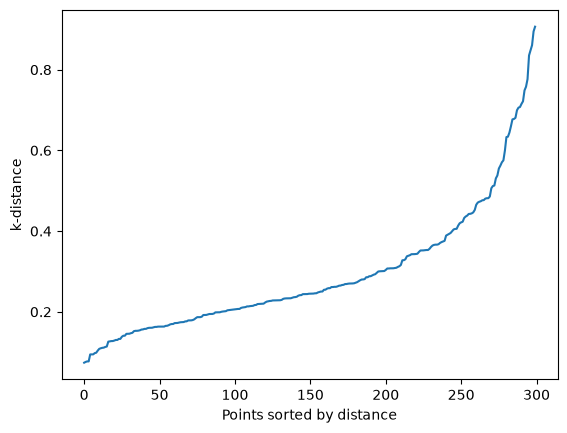

In [27]:
# Compute k-distance graph
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort and plot distances
distances = np.sort(distances[:, 3], axis=0)
plt.plot(distances)
plt.ylabel('k-distance')
plt.xlabel('Points sorted by distance')
plt.show();

In [28]:
from sklearn.cluster import DBSCAN
# Run DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan.fit(X)

# Extract labels and core samples
labels = dbscan.labels_
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.3
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[float64](166, 2)","[[-1.41, 7.41], [-1.02, 7.81], [ 1.41, 4.38], ..., [ 2.52, 1.39], [ 0.44, 4.54], [-1.79, 2.75]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](166,)","[ 1, 3, 7,...,296,297,299]"


In [29]:
# identify and separate outliers from clusters
outliers = X[labels == -1]
print("Outliers detected:\n", outliers)

Outliers detected:
 [[ 8.36856841e-01  2.13635938e+00]
 [ 1.27135141e+00  1.89254207e+00]
 [ 3.43761754e+00  2.61654166e-01]
 [-1.80822253e+00  1.59701749e+00]
 [-2.04932168e-01  8.43209665e+00]
 [-2.67000792e+00  8.35389140e+00]
 [-2.22783649e+00  6.89479938e+00]
 [ 1.45513831e+00 -2.91989981e-02]
 [-5.55523811e-01  4.69595848e+00]
 [-2.88024255e+00  2.30437816e+00]
 [ 1.87271752e+00  4.18069237e+00]
 [-1.13121396e+00  6.76652230e+00]
 [-2.62142780e+00  7.98635066e+00]
 [-4.74920358e-02  5.47425256e+00]
 [ 1.75644805e+00  2.05538289e+00]
 [-4.15017659e-02  7.80870276e+00]
 [-1.14091533e+00  1.97550822e+00]
 [-1.54994580e+00  9.28293222e+00]
 [-2.66676007e+00  7.84766052e+00]
 [-4.87271301e-01  3.32858293e+00]
 [ 1.25471244e+00  8.96331565e-02]
 [-2.04758277e+00  6.65428520e+00]
 [-1.95575053e+00  8.61631686e+00]
 [ 2.72396035e-01  5.46996004e+00]
 [-3.12240736e+00  3.28167398e+00]
 [ 1.66909648e+00 -4.36378231e-01]
 [ 2.43934644e+00 -7.25099666e-02]
 [-1.31454942e+00  6.83904013e+00]


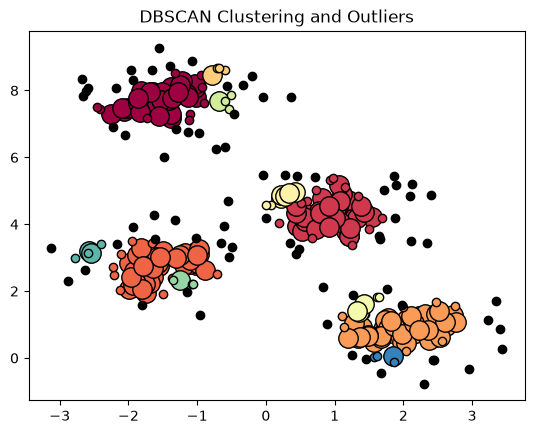

In [30]:
# Plotting the clusters
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Black for noise

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=14)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)
plt.title('DBSCAN Clustering and Outliers')
plt.show();

# 4 Advanced Algorithms


Outlier detector algorithms are of two types:
* Ones that consider each feature independently (such as HBOS, z-score, inter-quartile range, entropy-based tests and so on) works strictly with numeric data.
* Ones that consider all features at once (such as Isolation Forest IF, Local Outlier Factor LOF and KNN).
* popular `PyOD` (Python Outlier Detection) library

###[CountsOutlierDetector](https://github.com/Brett-Kennedy/CountsOutlierDetector/blob/main/README.md)
* is an interpretable, intuitive, efficient outlier detector intended for tabular data.
* designed to provide clear explanations of the rows flagged as outliers and of their specific scores.
* is a multivariate histogram-based model
* standard detectors as `Isolation Forest` (IF), `Local Outlier Factor` (LOF), and `k Nearest Neighbors` (kNN), have algorithms that are straight-forwared to understand, but produce scores that may be difficult to assess.
* `CountsOutlierDetector` attempts to solve these issues by providing a highly transparent, non-stocastic outlier detection system.

* Working
  * finds `1D outliers` (outliers based on considering a single dimension at a time) by examing   
    * *each column individually* and
    * *identifying all values that are unusual* with respect to their columns.
  * finds `2D outliers` by examining each pair of columns, *identifying the rows with pairs of unusual values* within each pair of columns.
    * For example, having fur may be common, as well as laying eggs, but the combination is rare.
    * with numeric columns, an age of 1 yr may be common and a height of 6' as well, but the combination rare, most likely flagging an error.
  * finds `nD outliers`: detector then considers sets of 3 columns, sets of 4 columns, and so on.
  * At each stage, the algorithm looks for instances that are unusual

**Categorical vs Numeric Outlier Detectors**
* most outlier detectors may be considered to be one of two types:
  * categorical
    * all columns are assumed to be categorical, and any numeric columns must be binned.
    * binning the values can loose some information, as the order of the bins is lost
    * can add greatly to model interpretability as it eliminates `data scaling` and `defining a distance metric` that removes any processing time required to calculate the distances between points
  * numeric-based detectors
    * all columns are assumed to be numeric, and any categorical columns must be numerically encoded using one-hot encoding or count encoding.
* `CountsOutlierDetector` is an example of the former, treating all features as categorical.
  * To determine if a value is rare, `COD` simply examines the count of its value;
  * to determine if a pair of values is rare, it simply examines the count of this pair of values, compared to other pairs of values in the two columns.
  * There may be some loss of fidelity in some cases, but overall, this allows for fast and interpretable results

  

```
CountsOutlierDetector(
             n_bins=7,
             bin_names=None,
             max_dimensions=3,
             threshold=0.05,
             check_marginal_probs=False,
             max_num_combinations=100_000,
             min_values_per_column=2,
             max_values_per_column=25,
             results_folder="",
             results_name="",
             run_parallel=False,
             verbose=False)
```
functions `predict(), get_most_flagged_rows(), plot_scores_distribution(),print_run_summary(),explain_row(row_index, max_plots=50),explain_features(features_arr)`
  


In [31]:
import os, sys
#from google.colab import drive
#drive.mount('/content/drive')
#nb_path = '/content/notebooks'
#os.symlink('/content/drive/My Drive/Colab Notebooks', nb_path)
sys.path.append('/content/drive/My Drive/Colab Notebooks')
#!pip install counts_outlier_detector

In [32]:
sys.path.insert(0, '..\\CountsOutlierDetector')
from counts_outlier_detector import CountsOutlierDetector

ModuleNotFoundError: No module named 'counts_outlier_detector'

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target
det = CountsOutlierDetector()
#dir(det) # shows all attributes of the package
results = det.fit_predict(X)
results

###[PyOD](https://pyod.readthedocs.io/en/latest/)
PyOD, established in 2017, has become a go-to Python library for detecting anomalous/outlying objects in multivariate data. This exciting yet challenging field is commonly referred to as `Outlier Detection` or `Anomaly Detection`.

* PyOD includes more than 50 detection algorithms, from classical LOF to the cutting-edge ECOD (Empirical-Cumulative-distribution-based Outlier Detection) and Deep Isolation Forest (DIF).

* PyOD offers a range of algorithms to suit your needs.
  * For time-series outlier detection, please use `TODS`.
  * For graph outlier detection, please use `PyGOD`.
* PyOD is featured for:
  * Unified, User-Friendly Interface across various algorithms.
  * Wide Range of Models, from classic techniques to the latest deep learning methods in `PyTorch`.
  * High Performance & Efficiency, leveraging `numba` and `joblib` for JIT compilation and parallel processing.
  * Fast Training & Prediction, achieved through the `SUOD` framework (accelerating large-scale unsupervised heterogeneous outlier detection).
* Installation
```
!pip install pyod
```


####[Implemented Algorithms](https://pyod.readthedocs.io/en/latest/#implemented-algorithms)
PyOD toolkit consists of three major functional groups:

####(i) Individual Detection Algorithms :

|Type |Abbr|Algorithm | Year | Class  | Ref  |
|----------|-------------|------------|------|------------|-------------|
| Probabilistic     | ECOD        | Unsupervised Outlier Detection Using Empirical Cumulative Distribution Functions                      | 2022 | pyod.models.ecod.ECOD                      | [ALZH+22]          |
| Probabilistic     | COPOD       | COPOD: Copula-Based Outlier Detection                                                                 | 2020 | pyod.models.copod.COPOD                    | [ALZB+20]          |
| Probabilistic     | ABOD        | Angle-Based Outlier Detection                                                                         | 2008 | pyod.models.abod.ABOD                      | [AKZ+08]           |
| Probabilistic     | FastABOD    | Fast Angle-Based Outlier Detection using approximation                                                | 2008 | pyod.models.abod.ABOD                      | [AKZ+08]           |
| Probabilistic     | MAD         | Median Absolute Deviation (MAD)                                                                       | 1993 | pyod.models.mad.MAD                        | [AIH93]            |
| Probabilistic     | SOS         | Stochastic Outlier Selection                                                                          | 2012 | pyod.models.sos.SOS                        | [AJHuszarPvdH12]   |
| Probabilistic     | QMCD        | Quasi-Monte Carlo Discrepancy outlier detection                                                       | 2001 | pyod.models.qmcd.QMCD                      | [AFM01]            |
| Probabilistic     | KDE         | Outlier Detection with Kernel Density Functions                                                       | 2007 | pyod.models.kde.KDE                        | [ALLP07]           |
| Probabilistic     | Sampling    | Rapid distance-based outlier detection via sampling                                                   | 2013 | pyod.models.sampling.Sampling              | [ASB13]            |
| Probabilistic     | GMM         | Probabilistic Mixture Modeling for Outlier Analysis                                                   |      | pyod.models.gmm.GMM                        | [AAgg15] [Ch.2]    |
| Linear Model      | PCA         | Principal Component Analysis (the sum of weighted projected distances to the eigenvector hyperplanes) | 2003 | pyod.models.pca.PCA                        | [ASCSC03]          |
| Linear Model      | KPCA        | Kernel Principal Component Analysis                                                                   | 2007 | pyod.models.kpca.KPCA                      | [AHof07]           |
| Linear Model      | MCD         | Minimum Covariance Determinant (use the mahalanobis distances as the outlier scores)                  | 1999 | pyod.models.mcd.MCD                        | [AHR04, ARD99]     |
| Linear Model      | CD          | Use Cook’s distance for outlier detection                                                             | 1977 | pyod.models.cd.CD                          | [ACoo77]           |
| Linear Model      | OCSVM       | One-Class Support Vector Machines                                                                     | 2001 | pyod.models.ocsvm.OCSVM                    | [AScholkopfPST+01] |
| Linear Model      | LMDD        | Deviation-based Outlier Detection (LMDD)                                                              | 1996 | pyod.models.lmdd.LMDD                      | [AAAR96]           |
| Proximity-Based   | LOF         | Local Outlier Factor                                                                                  | 2000 | pyod.models.lof.LOF                        | [ABKNS00]          |
| Proximity-Based   | COF         | Connectivity-Based Outlier Factor                                                                     | 2002 | pyod.models.cof.COF                        | [ATCFC02]          |
| Proximity-Based   | Incr. COF   | Memory Efficient Connectivity-Based Outlier Factor (slower but reduce storage complexity)             | 2002 | pyod.models.cof.COF                        | [ATCFC02]          |
| Proximity-Based   | CBLOF       | Clustering-Based Local Outlier Factor                                                                 | 2003 | pyod.models.cblof.CBLOF                    | [AHXD03]           |
| Proximity-Based   | LOCI        | LOCI: Fast outlier detection using the local correlation integral                                     | 2003 | pyod.models.loci.LOCI                      | [APKGF03]          |
| Proximity-Based   | HBOS        | Histogram-based Outlier Score                                                                         | 2012 | pyod.models.hbos.HBOS                      | [AGD12]            |
| Proximity-Based   | kNN         | k Nearest Neighbors (use the distance to the kth nearest neighbor as the outlier score                | 2000 | pyod.models.knn.KNN                        | [AAP02, ARRS00]    |
| Proximity-Based   | AvgKNN      | Average kNN (use the average distance to k nearest neighbors as the outlier score)                    | 2002 | pyod.models.knn.KNN                        | [AAP02, ARRS00]    |
| Proximity-Based   | MedKNN      | Median kNN (use the median distance to k nearest neighbors as the outlier score)                      | 2002 | pyod.models.knn.KNN                        | [AAP02, ARRS00]    |
| Proximity-Based   | SOD         | Subspace Outlier Detection                                                                            | 2009 | pyod.models.sod.SOD                        | [AKKrogerSZ09]     |
| Proximity-Based   | ROD         | Rotation-based Outlier Detection                                                                      | 2020 | pyod.models.rod.ROD                        | [AABC20]           |
| Outlier Ensembles | IForest     | Isolation Forest                                                                                      | 2008 | pyod.models.iforest.IForest                | [ALTZ08, ALTZ12]   |
| Outlier Ensembles | INNE        | Isolation-based Anomaly Detection Using Nearest-Neighbor Ensembles                                    | 2018 | pyod.models.inne.INNE                      | [ABTA+18]          |
| Outlier Ensembles | DIF         | Deep Isolation Forest for Anomaly Detection                                                           | 2023 | pyod.models.dif.DIF                        | []                 |
| Outlier Ensembles | FB          | Feature Bagging                                                                                       | 2005 | pyod.models.feature_bagging.FeatureBagging | [ALK05]            |
| Outlier Ensembles | LSCP        | LSCP: Locally Selective Combination of Parallel Outlier Ensembles                                     | 2019 | pyod.models.lscp.LSCP                      | [AZNHL19]          |
| Outlier Ensembles | XGBOD       | Extreme Boosting Based Outlier Detection (Supervised)                                                 | 2018 | pyod.models.xgbod.XGBOD                    | [AZH18]            |
| Outlier Ensembles | LODA        | Lightweight On-line Detector of Anomalies                                                             | 2016 | pyod.models.loda.LODA                      | [APevny16]         |
| Outlier Ensembles | SUOD        | SUOD: Accelerating Large-scale Unsupervised Heterogeneous Outlier Detection (Acceleration)            | 2021 | pyod.models.suod.SUOD                      | [AZHC+21]          |
| Neural Networks   | AutoEncoder | Fully connected AutoEncoder (use reconstruction error as the outlier score)                           | 2015 | pyod.models.auto_encoder.AutoEncoder       | [AAgg15] [Ch.3]    |
| Neural Networks   | VAE         | Variational AutoEncoder (use reconstruction error as the outlier score)                               | 2013 | pyod.models.vae.VAE                        | [AKW13]            |
| Neural Networks   | Beta-VAE    | Variational AutoEncoder (all customized loss term by varying gamma and capacity)                      | 2018 | pyod.models.vae.VAE                        | [ABHP+18]          |
| Neural Networks   | SO_GAAL     | Single-Objective Generative Adversarial Active Learning                                               | 2019 | pyod.models.so_gaal.SO_GAAL                | [ALLZ+19]          |
| Neural Networks   | MO_GAAL     | Multiple-Objective Generative Adversarial Active Learning                                             | 2019 | pyod.models.mo_gaal.MO_GAAL                | [ALLZ+19]          |
| Neural Networks   | DeepSVDD    | Deep One-Class Classification                                                                         | 2018 | pyod.models.deep_svdd.DeepSVDD             | [ARVG+18]          |
| Neural Networks   | AnoGAN      | Anomaly Detection with Generative Adversarial Networks                                                | 2017 | pyod.models.anogan.AnoGAN                  | [ASSeebockW+17]    |
| Neural Networks   | ALAD        | Adversarially learned anomaly detection                                                               | 2018 | pyod.models.alad.ALAD                      | [AZRF+18]          |
| Neural Networks   | DevNet      | Deep Anomaly Detection with Deviation Networks                                                        | 2019 | pyod.models.devnet.DevNet                  | [APSVDH19]         |
| Neural Networks   | AE1SVM      | Autoencoder-based One-class Support Vector Machine                                                    | 2019 | pyod.models.ae1svm.AE1SVM                  | [ANV19]            |
| Graph-based       | R-Graph     | Outlier detection by R-graph                                                                          | 2017 | pyod.models.rgraph.RGraph                  | [AYRV17]           |
| Graph-based       | LUNAR       | LUNAR: Unifying Local Outlier Detection Methods via Graph Neural Networks                             | 2022 | pyod.models.lunar.LUNAR                    | [AGHNN22]          |



#### (ii) Outlier Ensembles & Outlier Detector Combination Frameworks:


| Type              | Abbr             | Algorithm                                                                                  | Year | Ref                                        |            |
|-------------------|------------------|--------------------------------------------------------------------------------------------|------|--------------------------------------------|------------|
| Outlier Ensembles |                  | Feature Bagging                                                                            | 2005 | pyod.models.feature_bagging.FeatureBagging | [ALK05]    |
| Outlier Ensembles | LSCP             | LSCP: Locally Selective Combination of Parallel Outlier Ensembles                          | 2019 | pyod.models.lscp.LSCP                      | [AZNHL19]  |
| Outlier Ensembles | XGBOD            | Extreme Boosting Based Outlier Detection (Supervised)                                      | 2018 | pyod.models.xgbod.XGBOD                    | [AZH18]    |
| Outlier Ensembles | LODA             | Lightweight On-line Detector of Anomalies                                                  | 2016 | pyod.models.loda.LODA                      | [APevny16] |
| Outlier Ensembles | SUOD             | SUOD: Accelerating Large-scale Unsupervised Heterogeneous Outlier Detection (Acceleration) | 2021 | pyod.models.suod.SUOD                      | [AZHC+21]  |
| Combination       | Average          | Simple combination by averaging the scores                                                 | 2015 | pyod.models.combination.average()          | [AAS15]    |
| Combination       | Weighted Average | Simple combination by averaging the scores with detector weights                           | 2015 | pyod.models.combination.average()          | [AAS15]    |
| Combination       | Maximization     | Simple combination by taking the maximum scores                                            | 2015 | pyod.models.combination.maximization()     | [AAS15]    |
| Combination       | AOM              | Average of Maximum                                                                         | 2015 | pyod.models.combination.aom()              | [AAS15]    |
| Combination       | MOA              | Maximum of Average                                                                         | 2015 | pyod.models.combination.moa()              | [AAS15]    |
| Combination       | Median           | Simple combination by taking the median of the scores                                      | 2015 | pyod.models.combination.median()           | [AAS15]    |
| Combination       | majority Vote    | Simple combination by taking the majority vote of the labels (weights can be used)         | 2015 | pyod.models.combination.majority_vote()    | [AAS15]    |

####(iii) Utility Functions:

| Type    | Name                                     | Function                                                                                                                              |
|---------|------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------|
| Data    | pyod.utils.data.generate_data()          | Synthesized data generation; normal data is generated by a multivariate Gaussian and outliers are generated by a uniform distribution |
| Data    | pyod.utils.data.generate_data_clusters() | Synthesized data generation in clusters; more complex data patterns can be created with multiple clusters                             |
| Stat    | pyod.utils.stat_models.wpearsonr()       | Calculate the weighted Pearson correlation of two samples                                                                             |
| Utility | pyod.utils.utility.get_label_n()         | Turn raw outlier scores into binary labels by assign 1 to top n outlier scores                                                        |
| Utility | pyod.utils.utility.precision_n_scores()  | calculate precision @ rank n                                                                                                          |

### Outlier Detection Using PyOD

In [ ]:
!pip install pyod
from pyod.utils.data import generate_data, get_outliers_inliers
from pyod.models.pca import PCA
from pyod.utils.data import evaluate_print
from pyod.utils.example import visualize

In [ ]:
# Start by creating a dataset using generate_data() from pyod
X_train, y_train = generate_data(train_only=True)
# Create dataframe from Pandas using the generated data
df_train = pd.DataFrame(X_train)
df_train['y'] = y_train

# Display first few rows
df_train.head()

## 5. Gaussian Distribution
Assumes data follows a bell-shaped normal distribution curve. Fits a Gaussian distribution model to the data and identifies points with very low probability as anomalies.

## 6. Autoencoders (in Neural Networks)
Encode and reconstruct data points, trained to minimize reconstruction error and flag anomalies. Implemented with libraries like Keras and PyTorch.

# Treatment

1. **Remove:** most appropriate when outlier is a result of a data entry error, a measurement error, or a sampling error. Removing a small number of outliers from a very large dataset can also be a reasonable approach. However, removing outliers from a small dataset can significantly reduce the sample size and weaken analysis.
    * Thresholding
    * Distance base
    * Clustering
2. **Replace:**
      * **imputation:** methods, such as using the `mean`, `median`, `mode`, or `constant value`
      * techniques like `nearest neighbors`, `linear regression`, or `machine learning models` can be employed to predict values based on other features or variables in the dataset.
3. **Transform**
    * **Scaling:** transforming outliers using mathematical functions or techniques alter the scale or shape of the data.
    * **Winsorization:** replacing extreme values with the nearest non-outlier value, typically based on a percentile threshold
    * **Transformations:** such as `logarithmic, square root, Box-Cox, and inverse` can reduce skewness or asymmetry, making the data more normal or symmetrical.
    * `Standardization, normalization, and scaling` can change the range or magnitude of the data, facilitating comparability or consistency.
4. **Robust models:**
    * **Robust statistics:** Use the `median` and `IQR` instead of the `mean` and `standard deviation` for statistical analysis.
    * Robust regression
    * M estimators
    * Outlier intensive clustering algorithm: e.g., DBSCAN

## 1 Remove/Trim/Delete
* completely remove outliers detected in the previous steps
  * IQR method
  * Z-score method
  * standard deviation method

In [ ]:
# Trimming the outliers from the sample data
for i in sample_outliers:
  a = np.delete(sample, np.where(np.atleast_1d(sample) == i))
  print(a) # print(len(sample), len(a))


### 1.1 Using IQR Method
* Scores not in the range of $(Q_1 - 1.5\ IQR)$ and $(Q_3 + 1.5\ IQR)$ are outliers, and can be removed.
* The IQR method is based on quartiles and works well for `skewed distributions`.

In [ ]:
dfnum_out = dfnum[~((dfnum.lt(Q1-1.5 * IQR))|(dfnum.gt (Q3 + 1.5 * IQR))).any(axis=1)]
dfnum_out.head(3)
dfnum_out.shape

To get the list of outliers deleted above

In [ ]:
# Calculate the outliers mask
outliers_mask = (dfnum.lt(Q1 - 1.5 * IQR)) | (dfnum.gt(Q3 + 1.5 * IQR))
outliers_mask.sample(10)  # True represents outlier

In [ ]:
# Extract the outliers (rows with outliers)
outliers = dfnum[outliers_mask]

# Display the outliers
print(outliers)

In [ ]:
# Sum the number of outliers for each column
outliers_count_columnwise =outliers_mask.sum(axis=0)
outliers_count_columnwise

### 1.2 Using Z-Score Method
* The Z-score method standardizes the data and removes values that are too far from the mean (typically with a Z-score threshold like 3).
* The Z-score method is suitable for `normally distributed` datasets.

In [ ]:
# Dictionary to hold the removed outliers column-wise
removed_outliers = {}

# Apply the detect_outliers_zscore function to each column and store outliers
for col in dfnum.columns:
    outliers = detect_outliers_zscore(dfnum[col])
    removed_outliers[col] = outliers

# Display the removed outliers column-wise
print("Removed outliers column-wise:")
for col, outliers in removed_outliers.items():
    print(f"{col}: {len(outliers)}")

### 1.3 Standard deviation method

In [ ]:
# Dictionary to hold the removed outliers column-wise
removed_outliers = {}
total_outliers = 0
# Apply the detect_outliers_zscore function to each column and store outliers
for col in dfnum.columns:
    outliers = detect_outliers_stdv(dfnum[col])
    removed_outliers[col] = outliers
    total_outliers += len(outliers)
# Display the removed outliers column-wise
print("Removed outliers column-wise:")
for col, outliers in removed_outliers.items():
    print(f"{col}: {len(outliers)}")

print(f"\n Total number of outliers in the DataFrame: {total_outliers}")

In [ ]:
# Calculate the outliers mask
outliers_mask = (dfnum.lt(Q1 - 1.5 * IQR)) | (dfnum.gt(Q3 + 1.5 * IQR))
outliers_mask.sample(10)  # True represents outlier

### 1.4 Other method
* Identify rows to drop using a specific column as index
* `.index` property retrieves the index labels of rows in `z` column that are ≤ 2.7, or ≥ 4.5.

In [ ]:
index = dfnum[(dfnum['z'] >= 4.5)|(dfnum['z'] <= 2.7)].index
dfnum.drop(index, inplace=True)
df['z'].describe()
df.z.skew()

##2 Replace

###2.1 Quantile-based Flooring and Capping (Winsorization)
* do the flooring (e.g., the 10th percentile) for the lower values and
* capping (e.g., the 90th percentile) for the higher values.

In [ ]:
quantiles_10=dfnum.quantile(.1)
quantiles_90=dfnum.quantile(.9)
# Combine the quantiles into a single DataFrame
quantiles_table = pd.DataFrame({
    '10 Percentile': quantiles_10,
    '90 Percentile': quantiles_90
})

quantiles_table
dfnum.skew()


The variable `price` has more skewness. To remove outliers by caping and then check the skewness reduced.

In [ ]:
dfnum['price'] = np.where(dfnum['price'] <755, 755,dfnum['price'])
dfnum['price'] = np.where(dfnum['price'] >6787, 6787,dfnum['price'])
dfnum.price.skew()

###2.2 Median Imputation
* Replace the extreme values with median values.

In [ ]:
print(df['table'].quantile(.5))
print(df['table'].quantile(.95))

In [ ]:
df['table'] = np.where(df['table'] > 60, 57, df['table'])
df.describe()

## 3 Imputation

### Log Transformation
* Transformation of the skewed variables may also help correct the distribution of the variables.
* These could be logarithmic, square root, or square transformations.
* The most common is the logarithmic transformation

In [ ]:
df["Log_table"] = df["table"].map(lambda i: np.log(i) if i > 0 else 0)
print(df['table'].skew())
print(df['Log_table'].skew())

#References

## Package Documentation
1. [PyOD](https://pyod.readthedocs.io/en/latest/#)
1. [ALIBI DETECT](https://github.com/SeldonIO/alibi-detect)
1. [PYCARET](https://pycaret.readthedocs.io/en/latest/index.html)
1. [FBPROPHET](https://pypi.org/project/fbprophet/)

## Articles
1. [PyOD: A Python Toolbox for Scalable Outlier Detection](https://www.jmlr.org/papers/volume20/19-011/19-011.pdf)
1. [ADGym: Design Choices for Deep Anomaly Detection](https://arxiv.org/pdf/2309.15376)
1. [ADBench: Anomaly Detection Benchmark](https://arxiv.org/abs/2206.09426)


##Blogs
1. [Time Series of Price Anomaly Detection](https://towardsdatascience.com/time-series-of-price-anomaly-detection-13586cd5ff46) @ Medium
1. [Introduction to Anomaly Detection in Python](https://cnvrg.io/anomaly-detection-python/) @ cnrvg
1. [DBSCAN for Outlier Detection in Python](https://medium.com/biased-algorithms/dbscan-for-outlier-detection-in-python-d24a9c949a50) @ Medium

## Books
1. [Outlier Detection in Python](https://www.manning.com/books/outlier-detection-in-python) by Brett Kennedy